In [1]:
import pandas as pd
import numpy as np

rfm = pd.read_csv("../data/processed/rfm_customer_data.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,5633.32,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [2]:
rfm["Churn"] = np.where(
    rfm["Recency"] > 90,
    1,
    0
)

rfm["Churn"].value_counts()

Churn
1    2989
0    2889
Name: count, dtype: int64

In [3]:
rfm["Churn"].value_counts()

Churn
1    2989
0    2889
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

X = rfm[
    ["Recency",
     "Frequency",
     "Monetary",
     "R_Score",
     "F_Score",
     "M_Score",
     "RFM_Score"]
]

y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4702, 7)
(1176, 7)


In [5]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [6]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [7]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import matplotlib.pyplot as plt

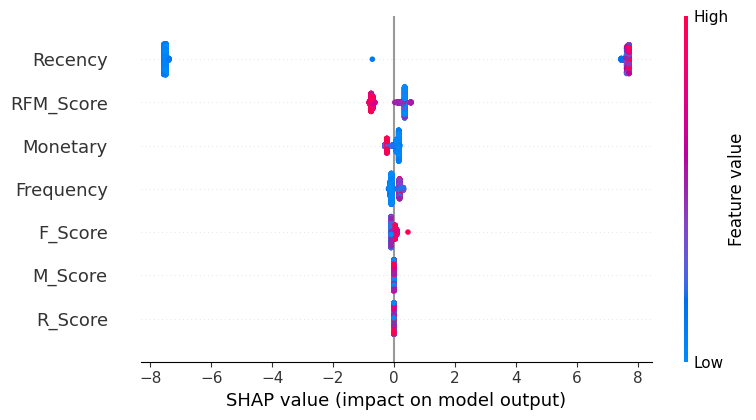

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../screenshots/shap_summary.png",
    bbox_inches="tight"
)

plt.show()

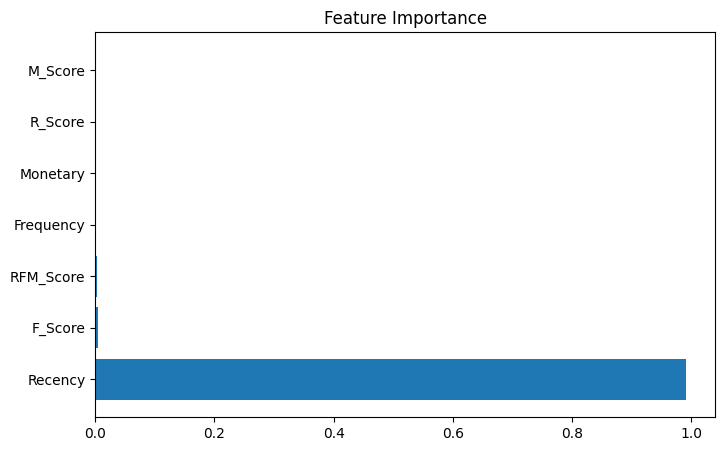

In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.savefig(
    "../screenshots/churn_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
pred_df = X_test.copy()

pred_df["Actual"] = y_test.values
pred_df["Predicted"] = predictions

pred_df.to_csv(
    "../data/processed/churn_predictions.csv",
    index=False
)

print("Churn predictions saved successfully!")

Churn predictions saved successfully!
